In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [3]:
img = cv2.imread('victoria.webp')

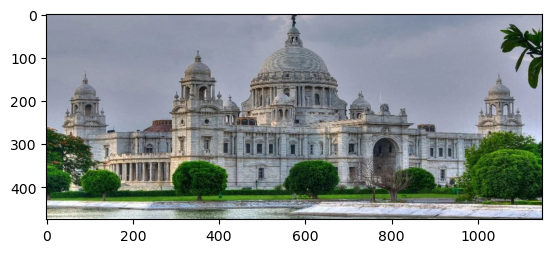

In [4]:
plt.imshow(img[:,:,::-1])

# Apply SIFT (Scale Invariant Feature Transform)

In [7]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
sift = cv2.SIFT_create()

In [16]:
kp, des = sift.detectAndCompute(gray,None)

In [18]:
img_sift = cv2.drawKeypoints(gray,kp,None)

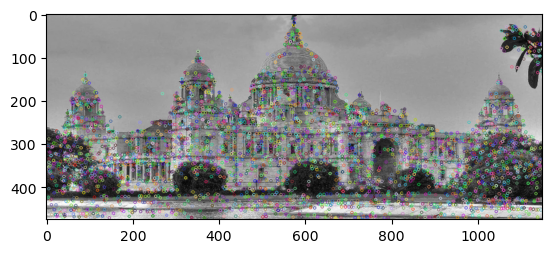

In [19]:
plt.imshow(img_sift)

In [20]:
cv2.imwrite('sift_keypoints_output.jpg', img_sift)

True

# Scale the image

In [22]:
img_sift.shape

(475, 1150, 3)

In [35]:
m,n = img_sift.shape[:2]
scaled_image = cv2.resize(img_sift, (2*n, 2*m), interpolation=cv2.INTER_CUBIC)

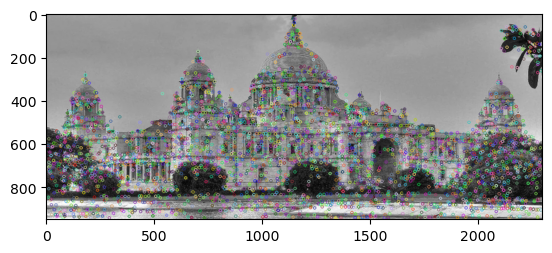

In [36]:
plt.imshow(scaled_image)

# Rotate by 30

In [43]:
rows, cols = img_sift.shape[:2]

M = cv2.getRotationMatrix2D((rows/2,cols/2),30,1)
dst = cv2.warpAffine(img_sift,M,(cols,rows))

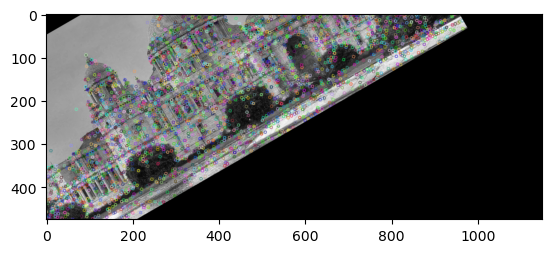

In [44]:
plt.imshow(dst)

# Brute Force Matching

In [45]:
# create BFMatcher object
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
# Match descriptors.
matches = bf.match(dst,img_sift)
# Sort them in the order of their distance.
matches = sorted(matches, key = lambda x:x.distance)

error: OpenCV(4.6.0) ./modules/core/src/batch_distance.cpp:274: error: (-215:Assertion failed) type == src2.type() && src1.cols == src2.cols && (type == CV_32F || type == CV_8U) in function 'batchDistance'
